In [1]:
%load_ext autoreload
# %reload_ext autoreload
%autoreload 1

%aimport b6_epilepsies 
import b6_epilepsies as b6 #.py file in the same dir as this .ipynb
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# sns.set_theme(style="whitegrid", context="notebook", palette="muted")

# Define the custom color palette and genotype order
# new_colors_order = sns.color_palette(palette='Set2', n_colors=3)
# new_colors_order[0], new_colors_order[1], new_colors_order[2] = new_colors_order[1], new_colors_order[0], new_colors_order[2]
# color_map = dict(zip(['wt', 'het', 'hom'], new_colors_order))

# Define input variables
date   = "250214"
box1   = "14"
box2   = "15"
exp    = "ALDH7A1_20LYS_7dpf"
export = False

omit = {box1:['H7','D8','D9','D12']}
    
ald_lys_obj_raw = b6.RawData(date, box1, box2, exp, export) #.prepped_data attribute to access df

# ald_lys_obj_mid  = b6.MiddurData(date, box1, box2, exp, export, omit=omit) #.prepped_data attribute to access df


Initialising RawData...
Start of experiment: 2025-02-14 10:07:08
Instantiated using 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_processed.csv, no need to prepare raw data.
Done.


In [7]:
df_mid, df_filtered_mid = ald_lys_obj_mid.prepped_data, ald_lys_obj_mid.prepped_filtered_data

In [ ]:
ald_lys_obj_mid.quick_plot_per_fish()

In [ ]:
grouped_df_filtered = df_filtered_mid.groupby(['genotype','stdate_sttime'])['middur'].agg(['mean', 'median', 'std', 'min', 'max', 'count','sum'])


plot_timeseries(grouped_df_filtered)

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def plot_timeseries(grouped_df_filtered):
    ungrouped = grouped_df_filtered.reset_index()

    # Plot using seaborn
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=ungrouped,
        x='stdate_sttime',  # x-axis: timestamps
        y='mean',           # y-axis: the mean of 'middur'
        hue='genotype',     # Different lines for each genotype
        hue_order = ['WT','HET','HOM'],
        linewidth=1,
        palette=new_colors_order
    )
    
    
    # Customize the x-axis format
    ax = plt.gca()  # Get the current axes
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Automatically locate date ticks
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as 'Date on one line, Time on the next'
    
    # Customize plot
    plt.title("ALDH7A1: Average Activity Over Time per Genotype (Filtered)")
    plt.xlabel("Timestamp")
    plt.ylabel("Mean Activity (s/min)")
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend(title="Genotype")
    plt.grid(True)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

    
    ### Smooth plot
    
    # Apply a rolling average for smoothing
    ungrouped['smoothed_mean'] = ungrouped.groupby('genotype')['mean'].apply(
        lambda x: x.rolling(window=40, min_periods=1).mean()
    )
    
    # Calculate Standard Error (SE)
    ungrouped['se'] = ungrouped['std'] / np.sqrt(ungrouped['count'])
    
    # Plot using seaborn
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=ungrouped,
        x='stdate_sttime',  # x-axis: timestamps
        y='smoothed_mean',           # y-axis: the mean of 'middur'
        hue_order=['WT','HET','HOM'],
        hue='genotype',     # Different lines for each genotype
        linewidth=1,
        ci=None,
        palette=new_colors_order
    )
    
    
    # Add shaded standard error for each genotype
    for genotype, group in ungrouped.groupby('genotype'):
        # print(genotype, group)
        plt.fill_between(
            group['stdate_sttime'],
            group['smoothed_mean'] - group['se'],  # Lower bound (mean - SE)
            group['smoothed_mean'] + group['se'],  # Upper bound (mean + SE)
            color = color_map[genotype],
            alpha=0.2,                             # Transparency for the shading
            label=f"{genotype} SE"          # Label for the spread
        )
    
    # Customize the x-axis format
    ax = plt.gca()  # Get the current axes
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Automatically locate date ticks
    # ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as 'Date on one line, Time on the next'
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))  # Format as 'Date on one line, Time on the next'

    
    # Customize plot
    plt.title("Smoothed Average Activity Over Time with Standard Error")
    plt.xlabel("Timestamp")
    plt.ylabel("Smoothed Average Activity (s/min)")
    plt.xticks(rotation=45)
    # plt.legend(title="Genotype and SE Spread")
    
    
    
    plt.grid(True)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

In [256]:
df_raw_test = ald_lys_obj_raw.df
# df_raw_14 = df_raw[df_raw['box']=='14']
# df_raw.to_csv('250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_processed.csv')
# df_raw_test.drop(columns=['zhrs', 'exsecs','abstime', 'time','type','plate','location'])
df_raw_test.head(50)

type(df_raw_test['box'])
df_raw_test['box']

96          14
97          14
98          14
99          14
100         14
            ..
54759556    14
54759558    14
54759560    14
54759562    14
54759564    14
Name: box, Length: 18415971, dtype: object

/Users/jadelau/Development/Neuroscience/B6 Epilepsies/b6_epilepsies.py:601: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  sns.lineplot(ax=axes[0], x='elapsed_time', y='data1', data=fish_data, hue=hue, palette=palette)


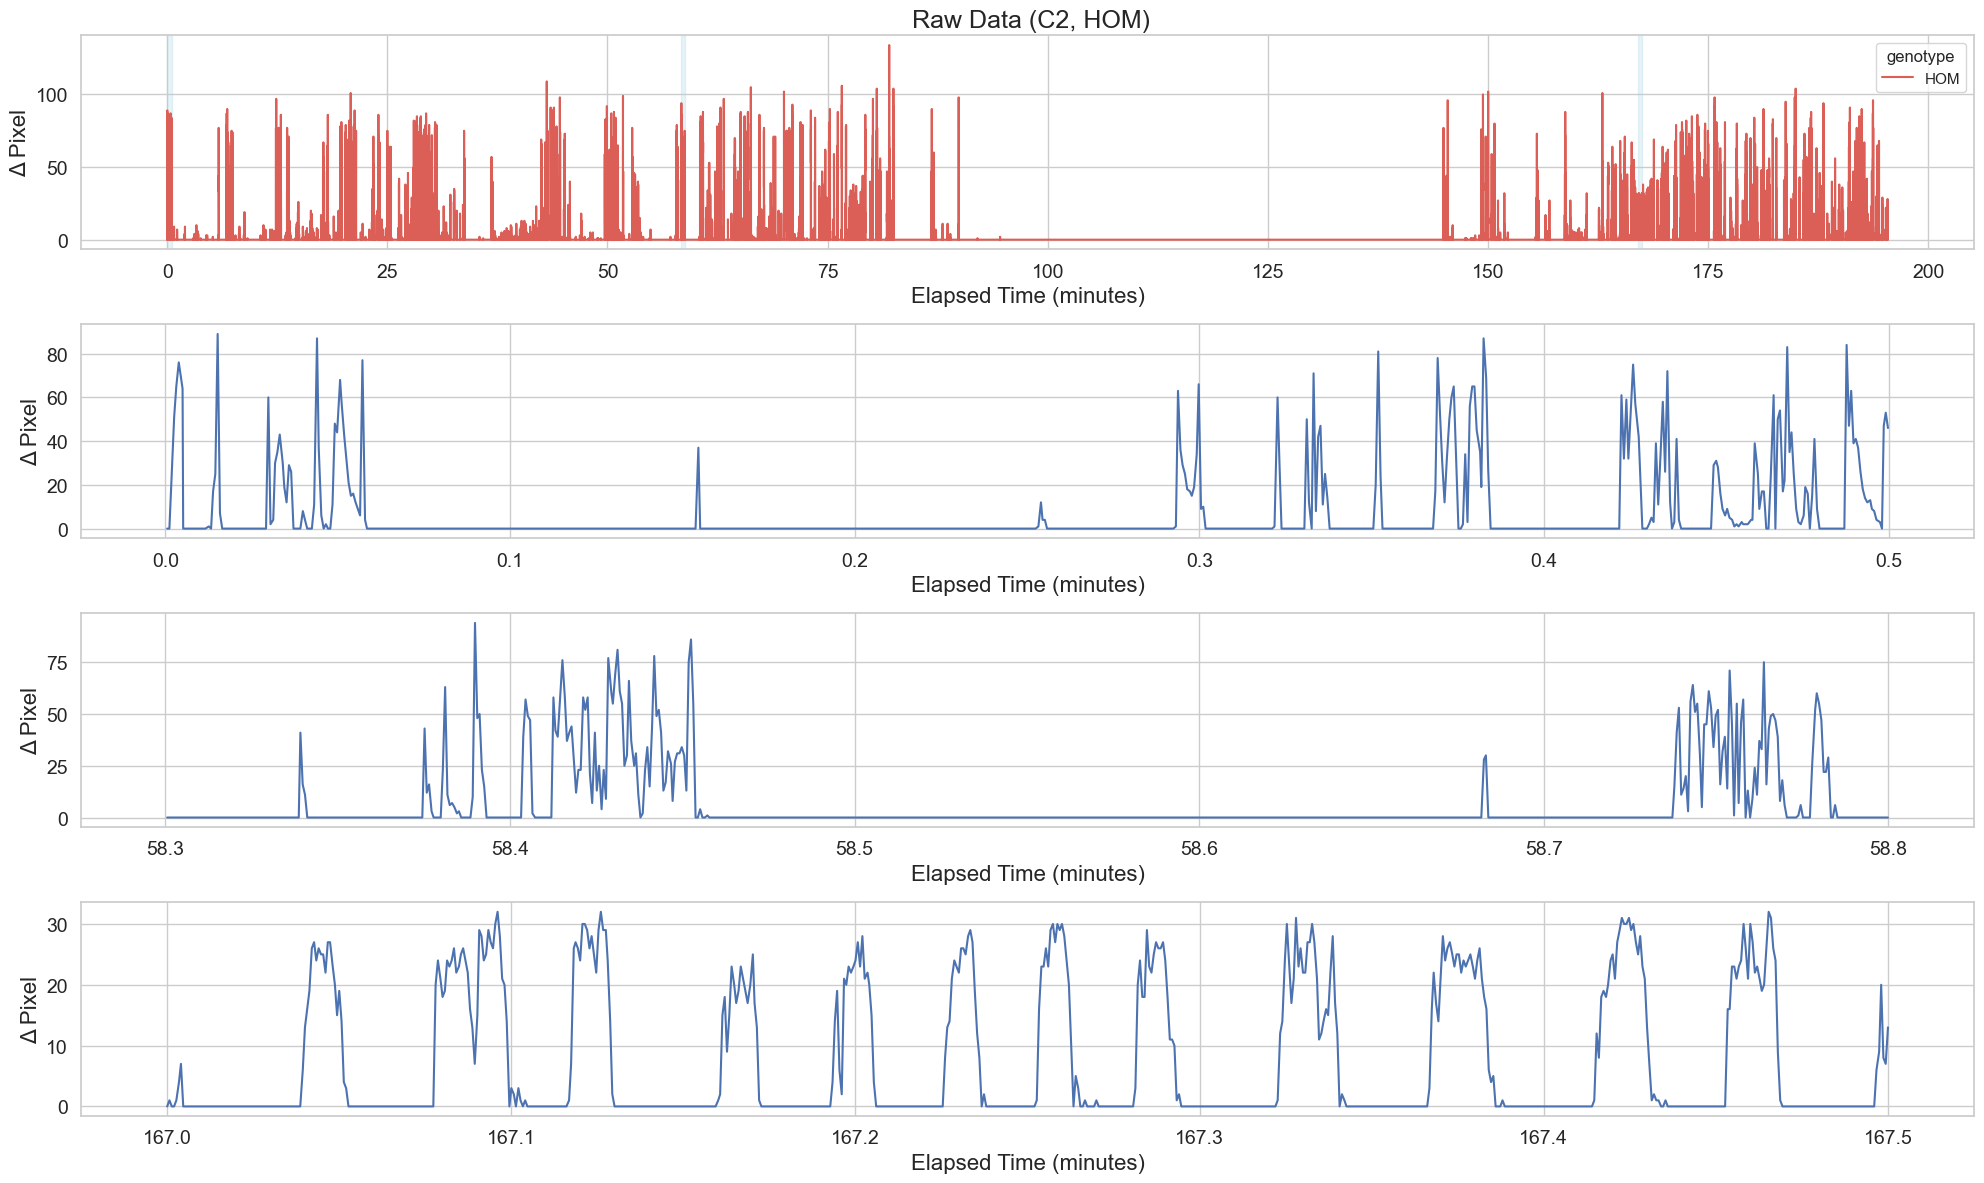

In [5]:
ald_lys_obj_raw.plot_single_fish_activity(well='C2', event_windows=[
    (0, 0.5, "Seizure Event, Example 1"),
    (58.3, 58.8, "Seizure Event, Example 2"),
    # (145, 145.5, "Seizure Event, Example 3"),
    (167, 167.5, "Post-ictal (?) Swimming, Example 4")
])

# ald_lys_obj_raw.plot_single_fish_activity(well='A3', event_windows=[
#     (20, 20.5, "Example 1"),
#     (80.3, 80.8, "Example 2"),
#     (130, 130.5, "Example 3"),
#     (160, 160.5, "Example 4")
# ])

/Users/jadelau/Development/Neuroscience/B6 Epilepsies/b6_epilepsies.py:601: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  sns.lineplot(ax=axes[0], x='elapsed_time', y='data1', data=fish_data, hue=hue, palette=palette)


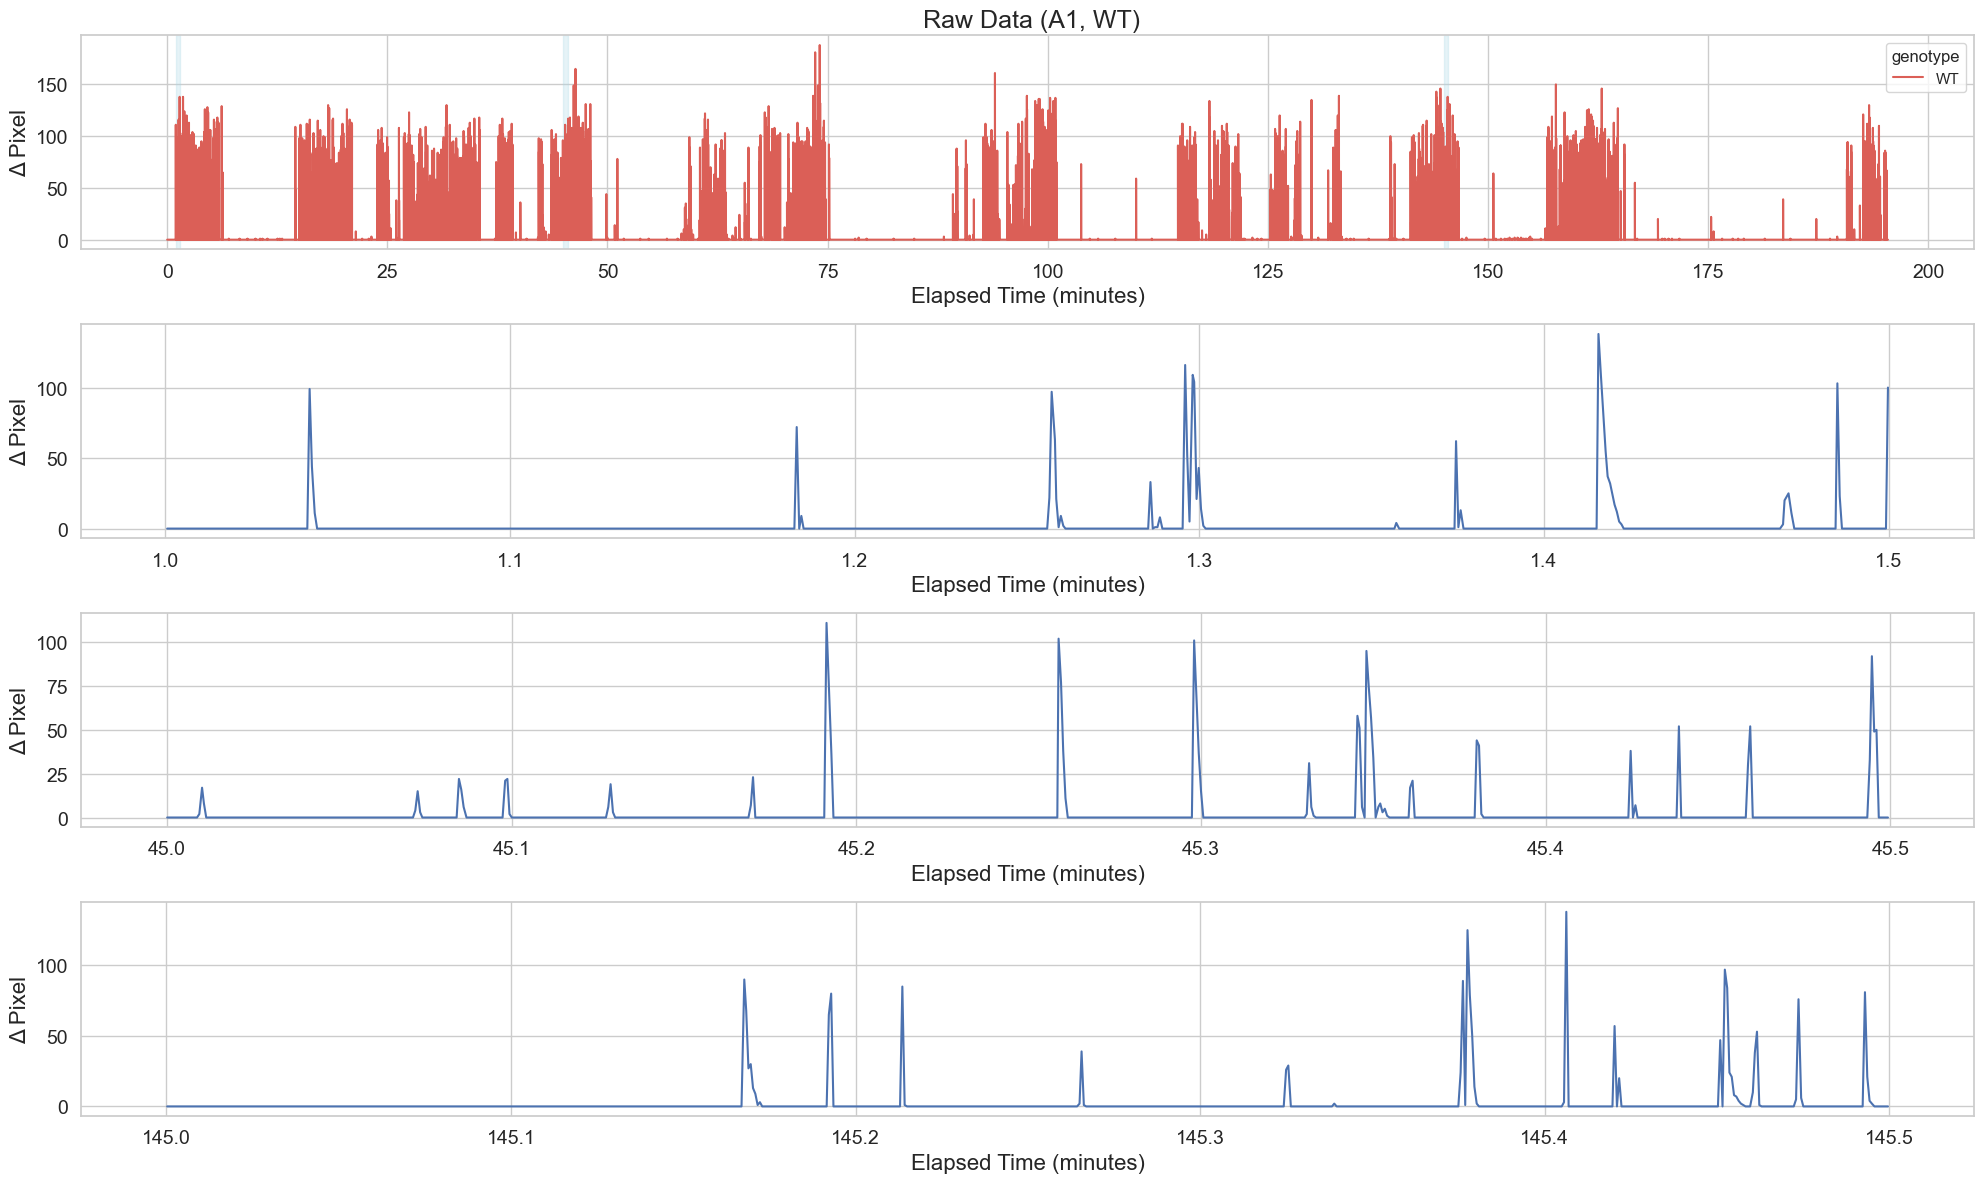

In [4]:
ald_lys_obj_raw.plot_single_fish_activity(well='A1', event_windows=[
    (1, 1.5, "Normal Swimming, Example 1"),
    (45, 45.5, "Normal Swimming, Example 2"),
    (145, 145.5, "Normal Swimming, Example 3")
])

In [ ]:
ald_lys_obj_raw.plot_single_fish_activity(well='D6', event_windows=[
    (25, 25.5, "Seizure Event, Example 1"),
    (30, 30.5, "Seizure Event, Example 2"),
    (115, 115.5, "Normal Swimming, Example 3")
])

/Users/jadelau/Development/Neuroscience/B6 Epilepsies/b6_epilepsies.py:507: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  sns.lineplot(ax=axes[0], x='elapsed_time', y='data1', data=fish_data, hue=hue, palette=palette)


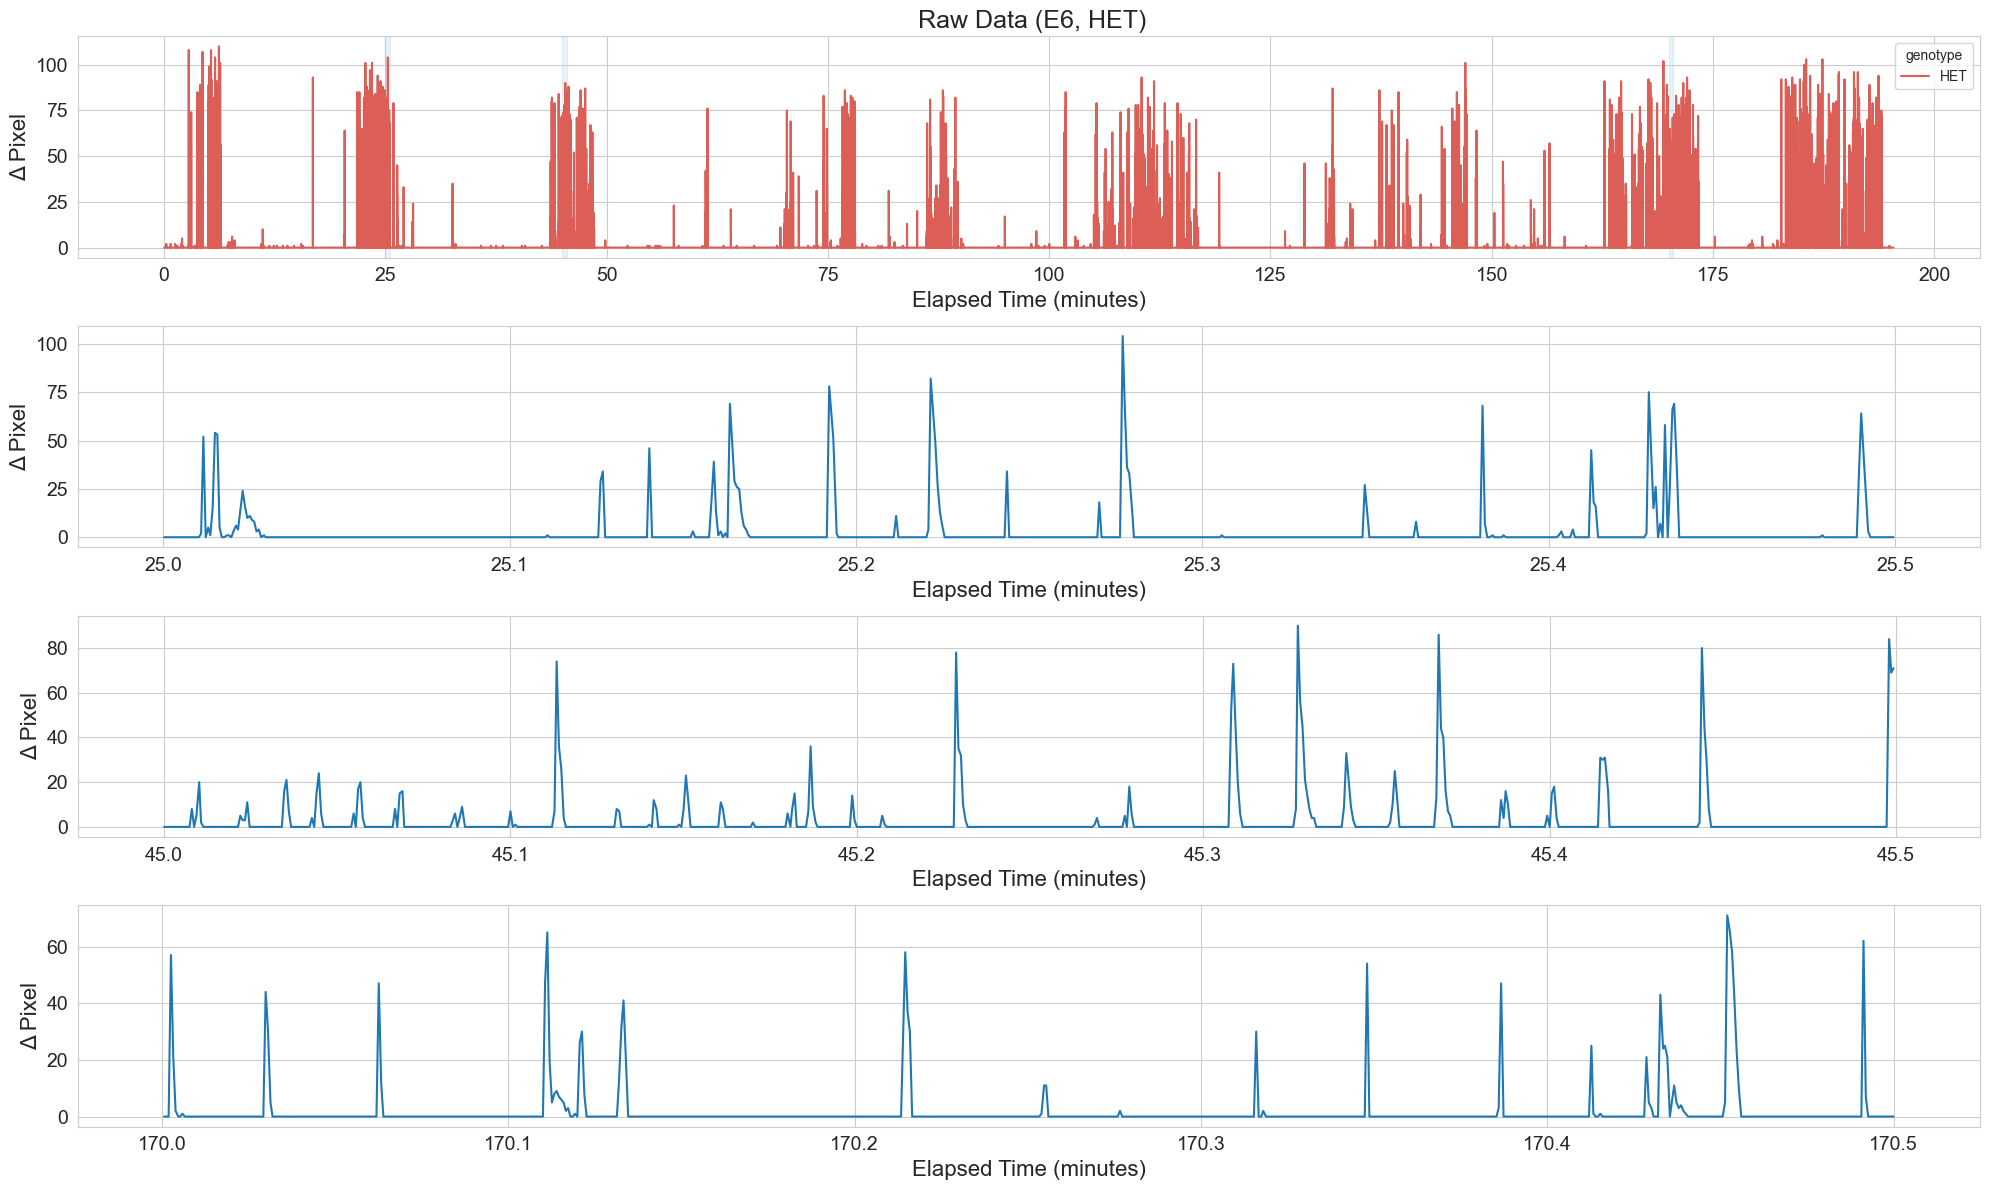

In [124]:
ald_lys_obj_raw.plot_single_fish_activity(well='E6', event_windows=[
    (25, 25.5, "Normal Swimming, Example 1"),
    (45, 45.5, "Normal Swimming, Example 2"),
    (170, 170.5, "Normal Swimming, Example 3")
])


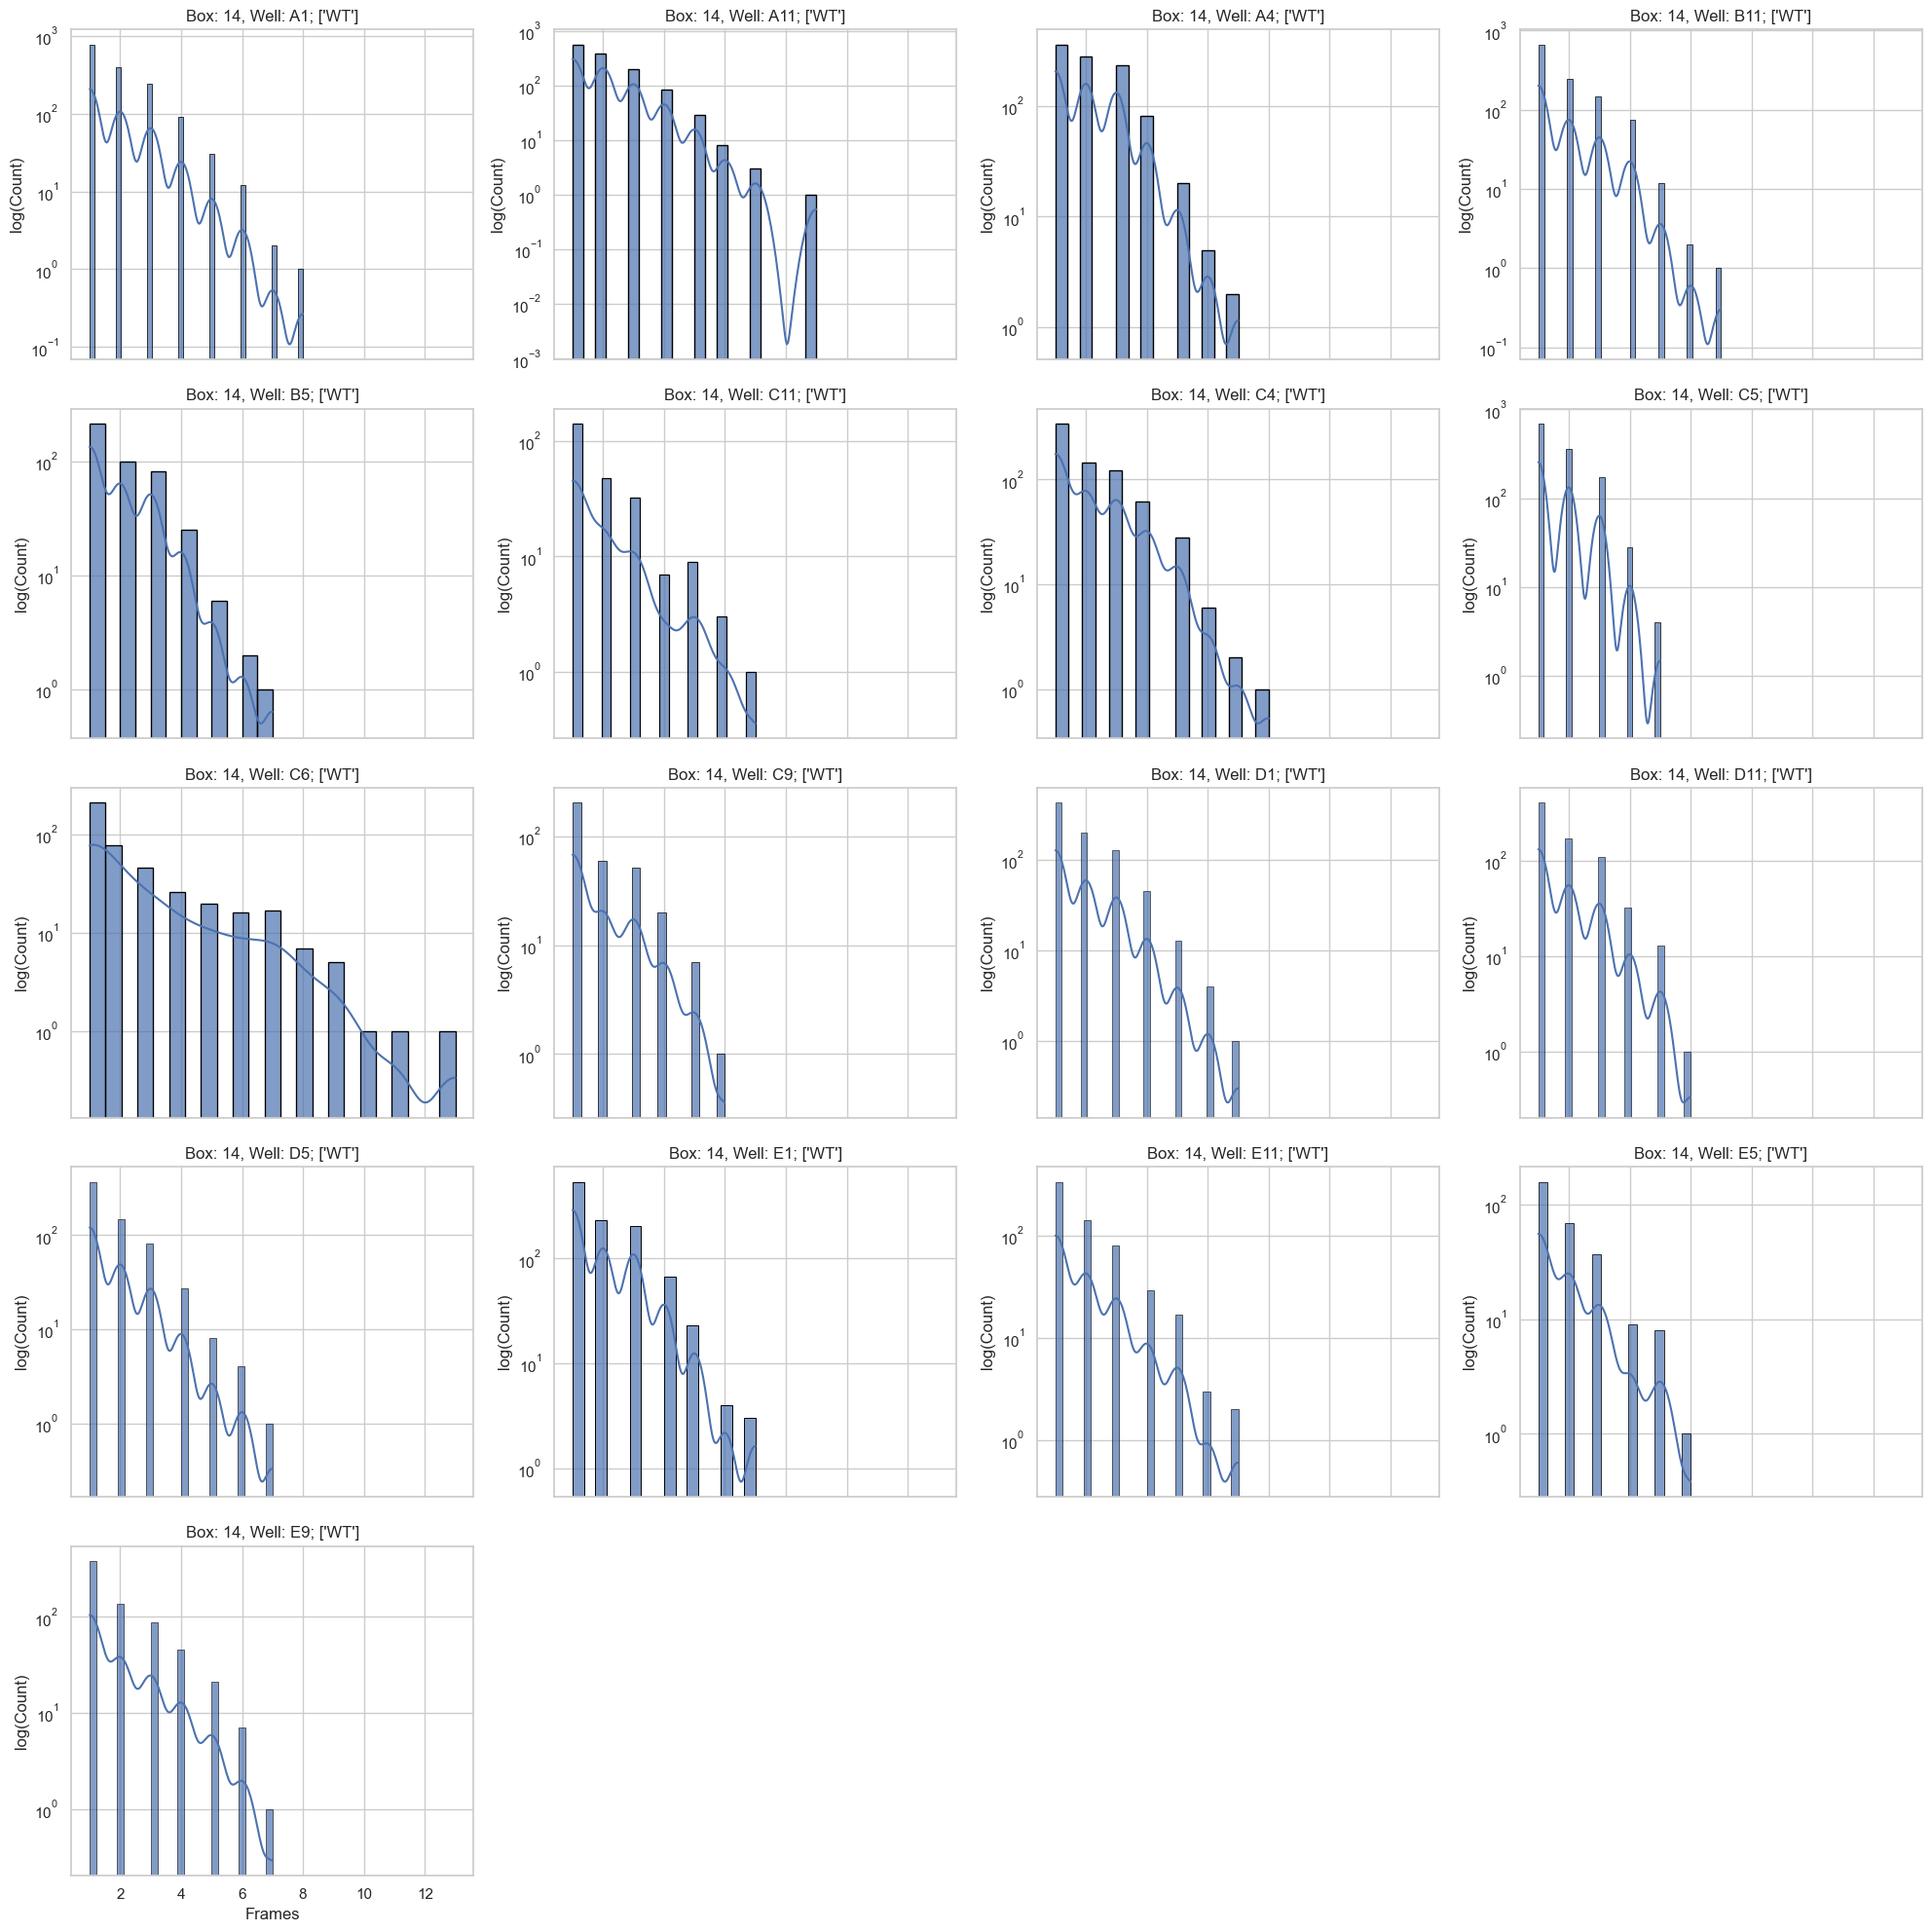

In [257]:
all_wts = df_raw[df_raw["genotype"] == "WT"]
all_wts_grouped = list(all_wts.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_wts_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list)


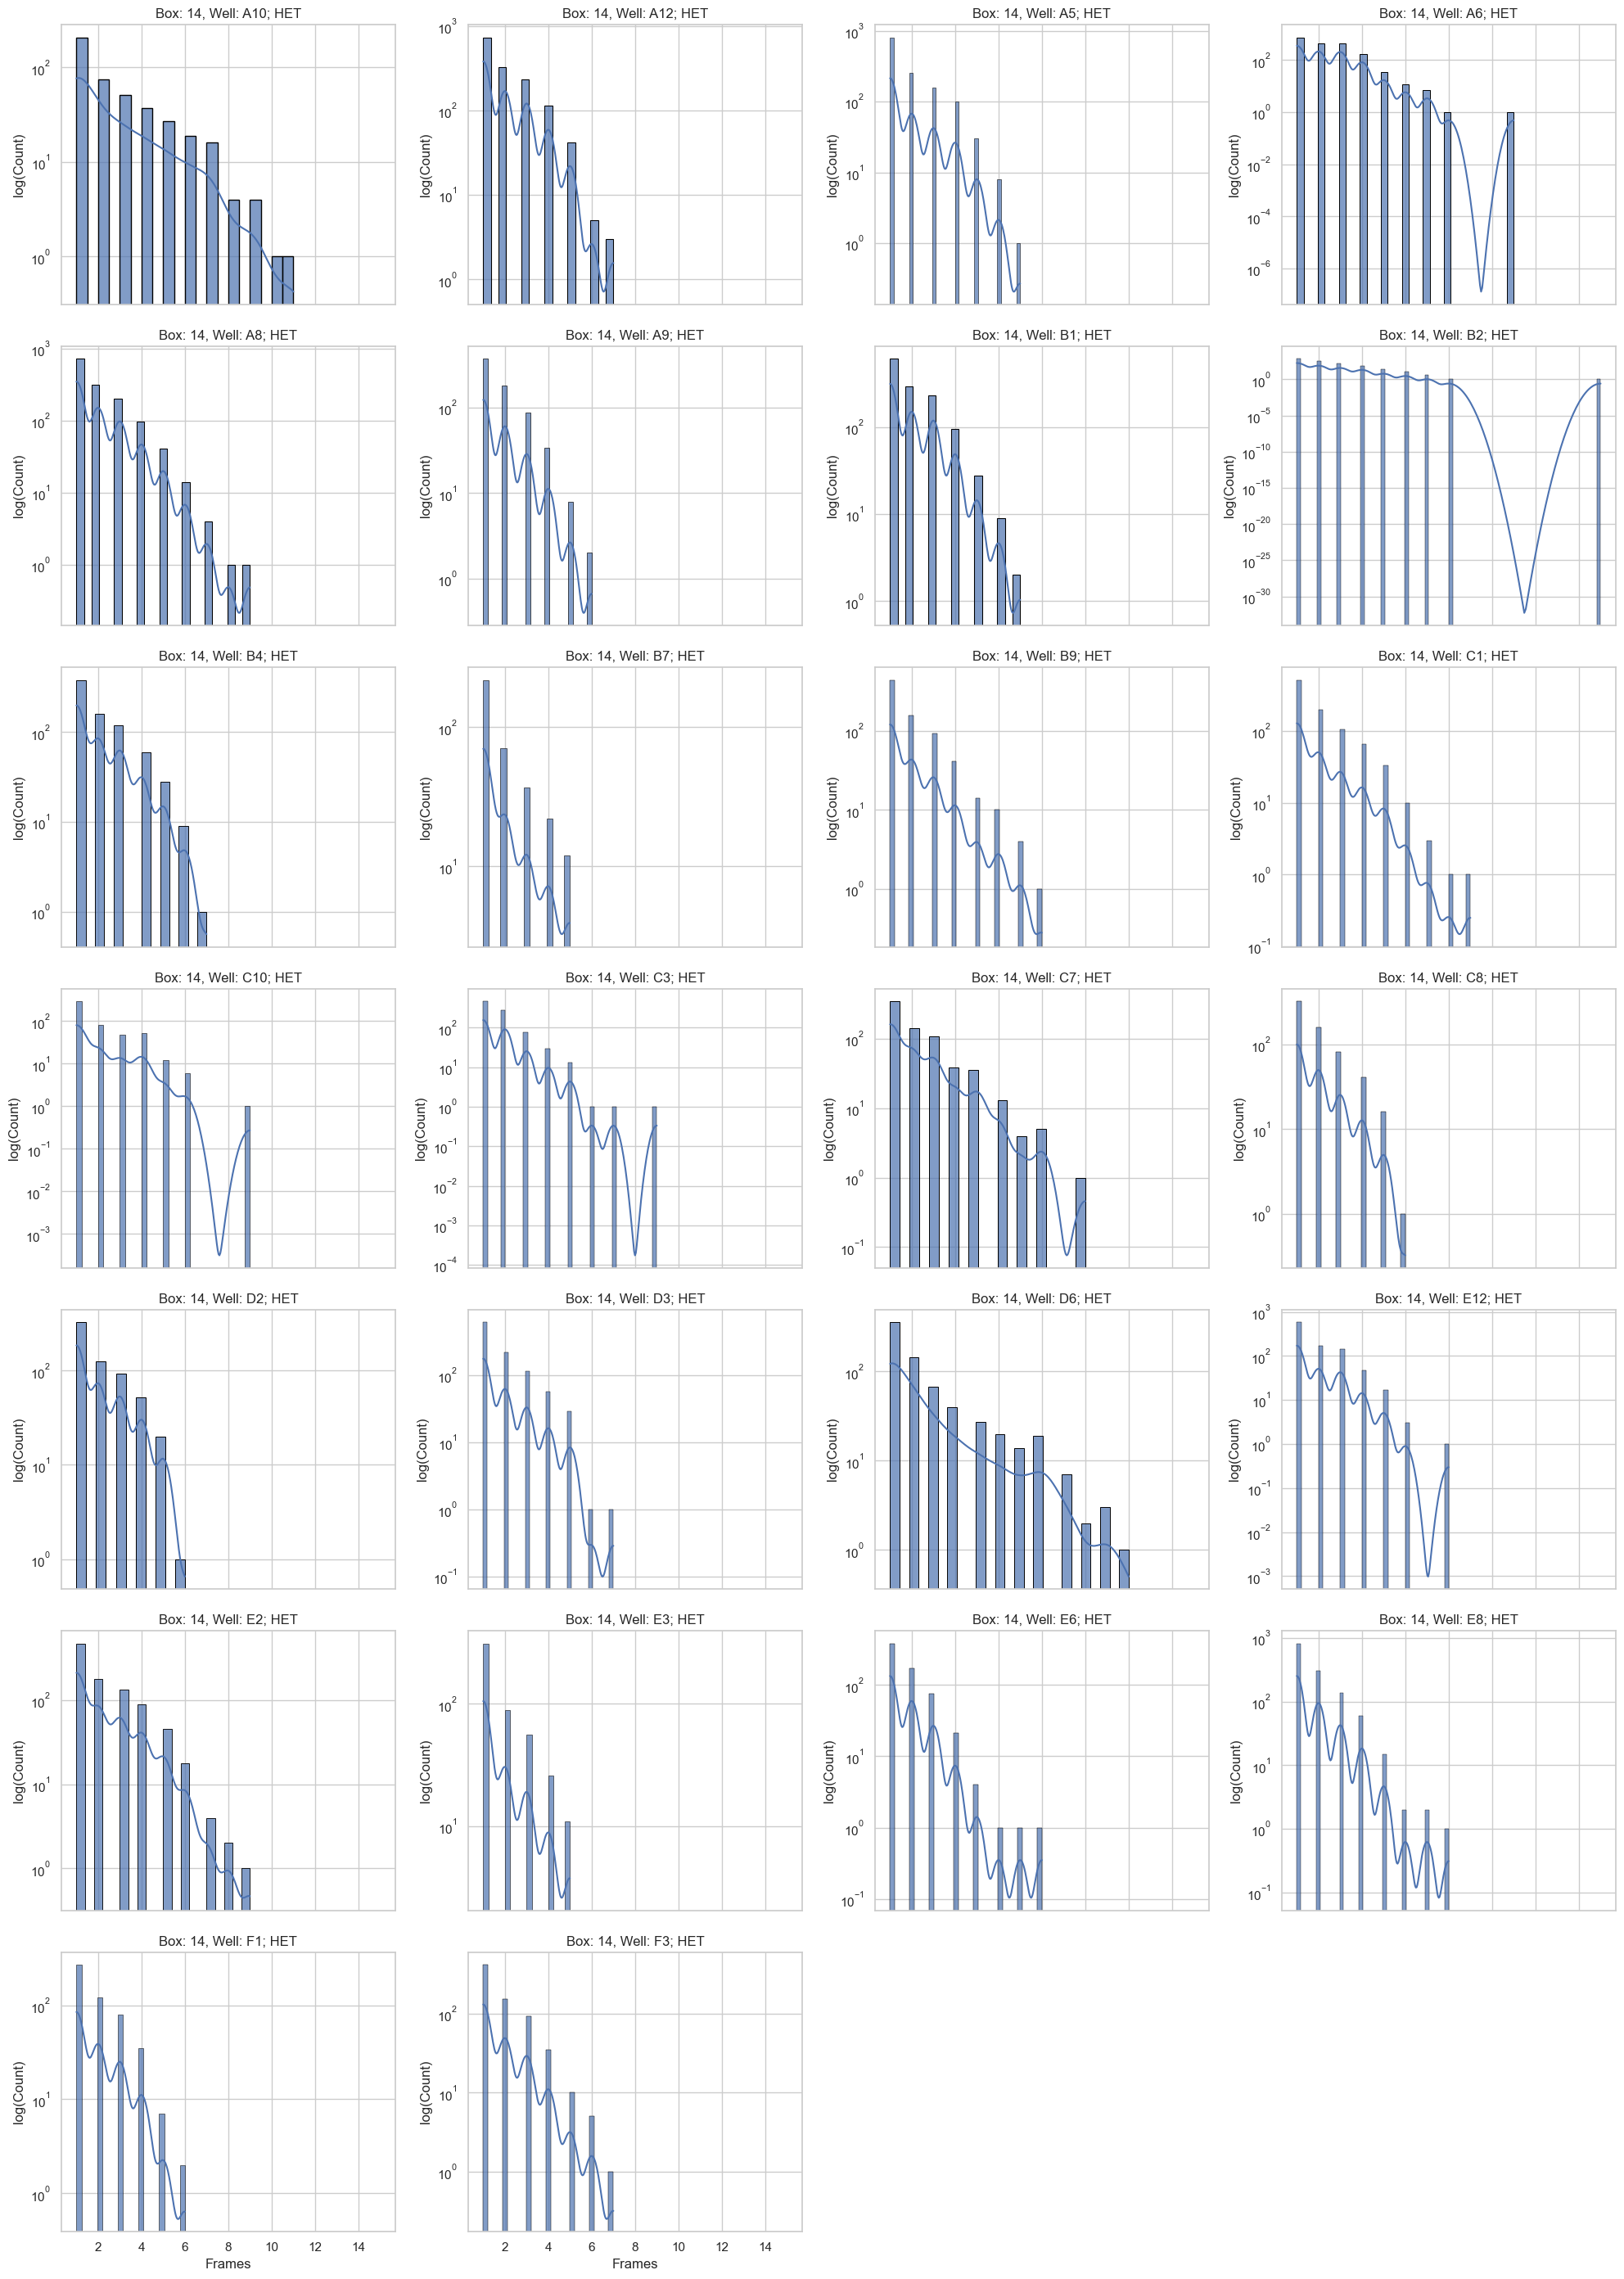

In [249]:
all_hets = df_raw[df_raw["genotype"] == "HET"]
all_hets_grouped = list(all_hets.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_hets_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list)

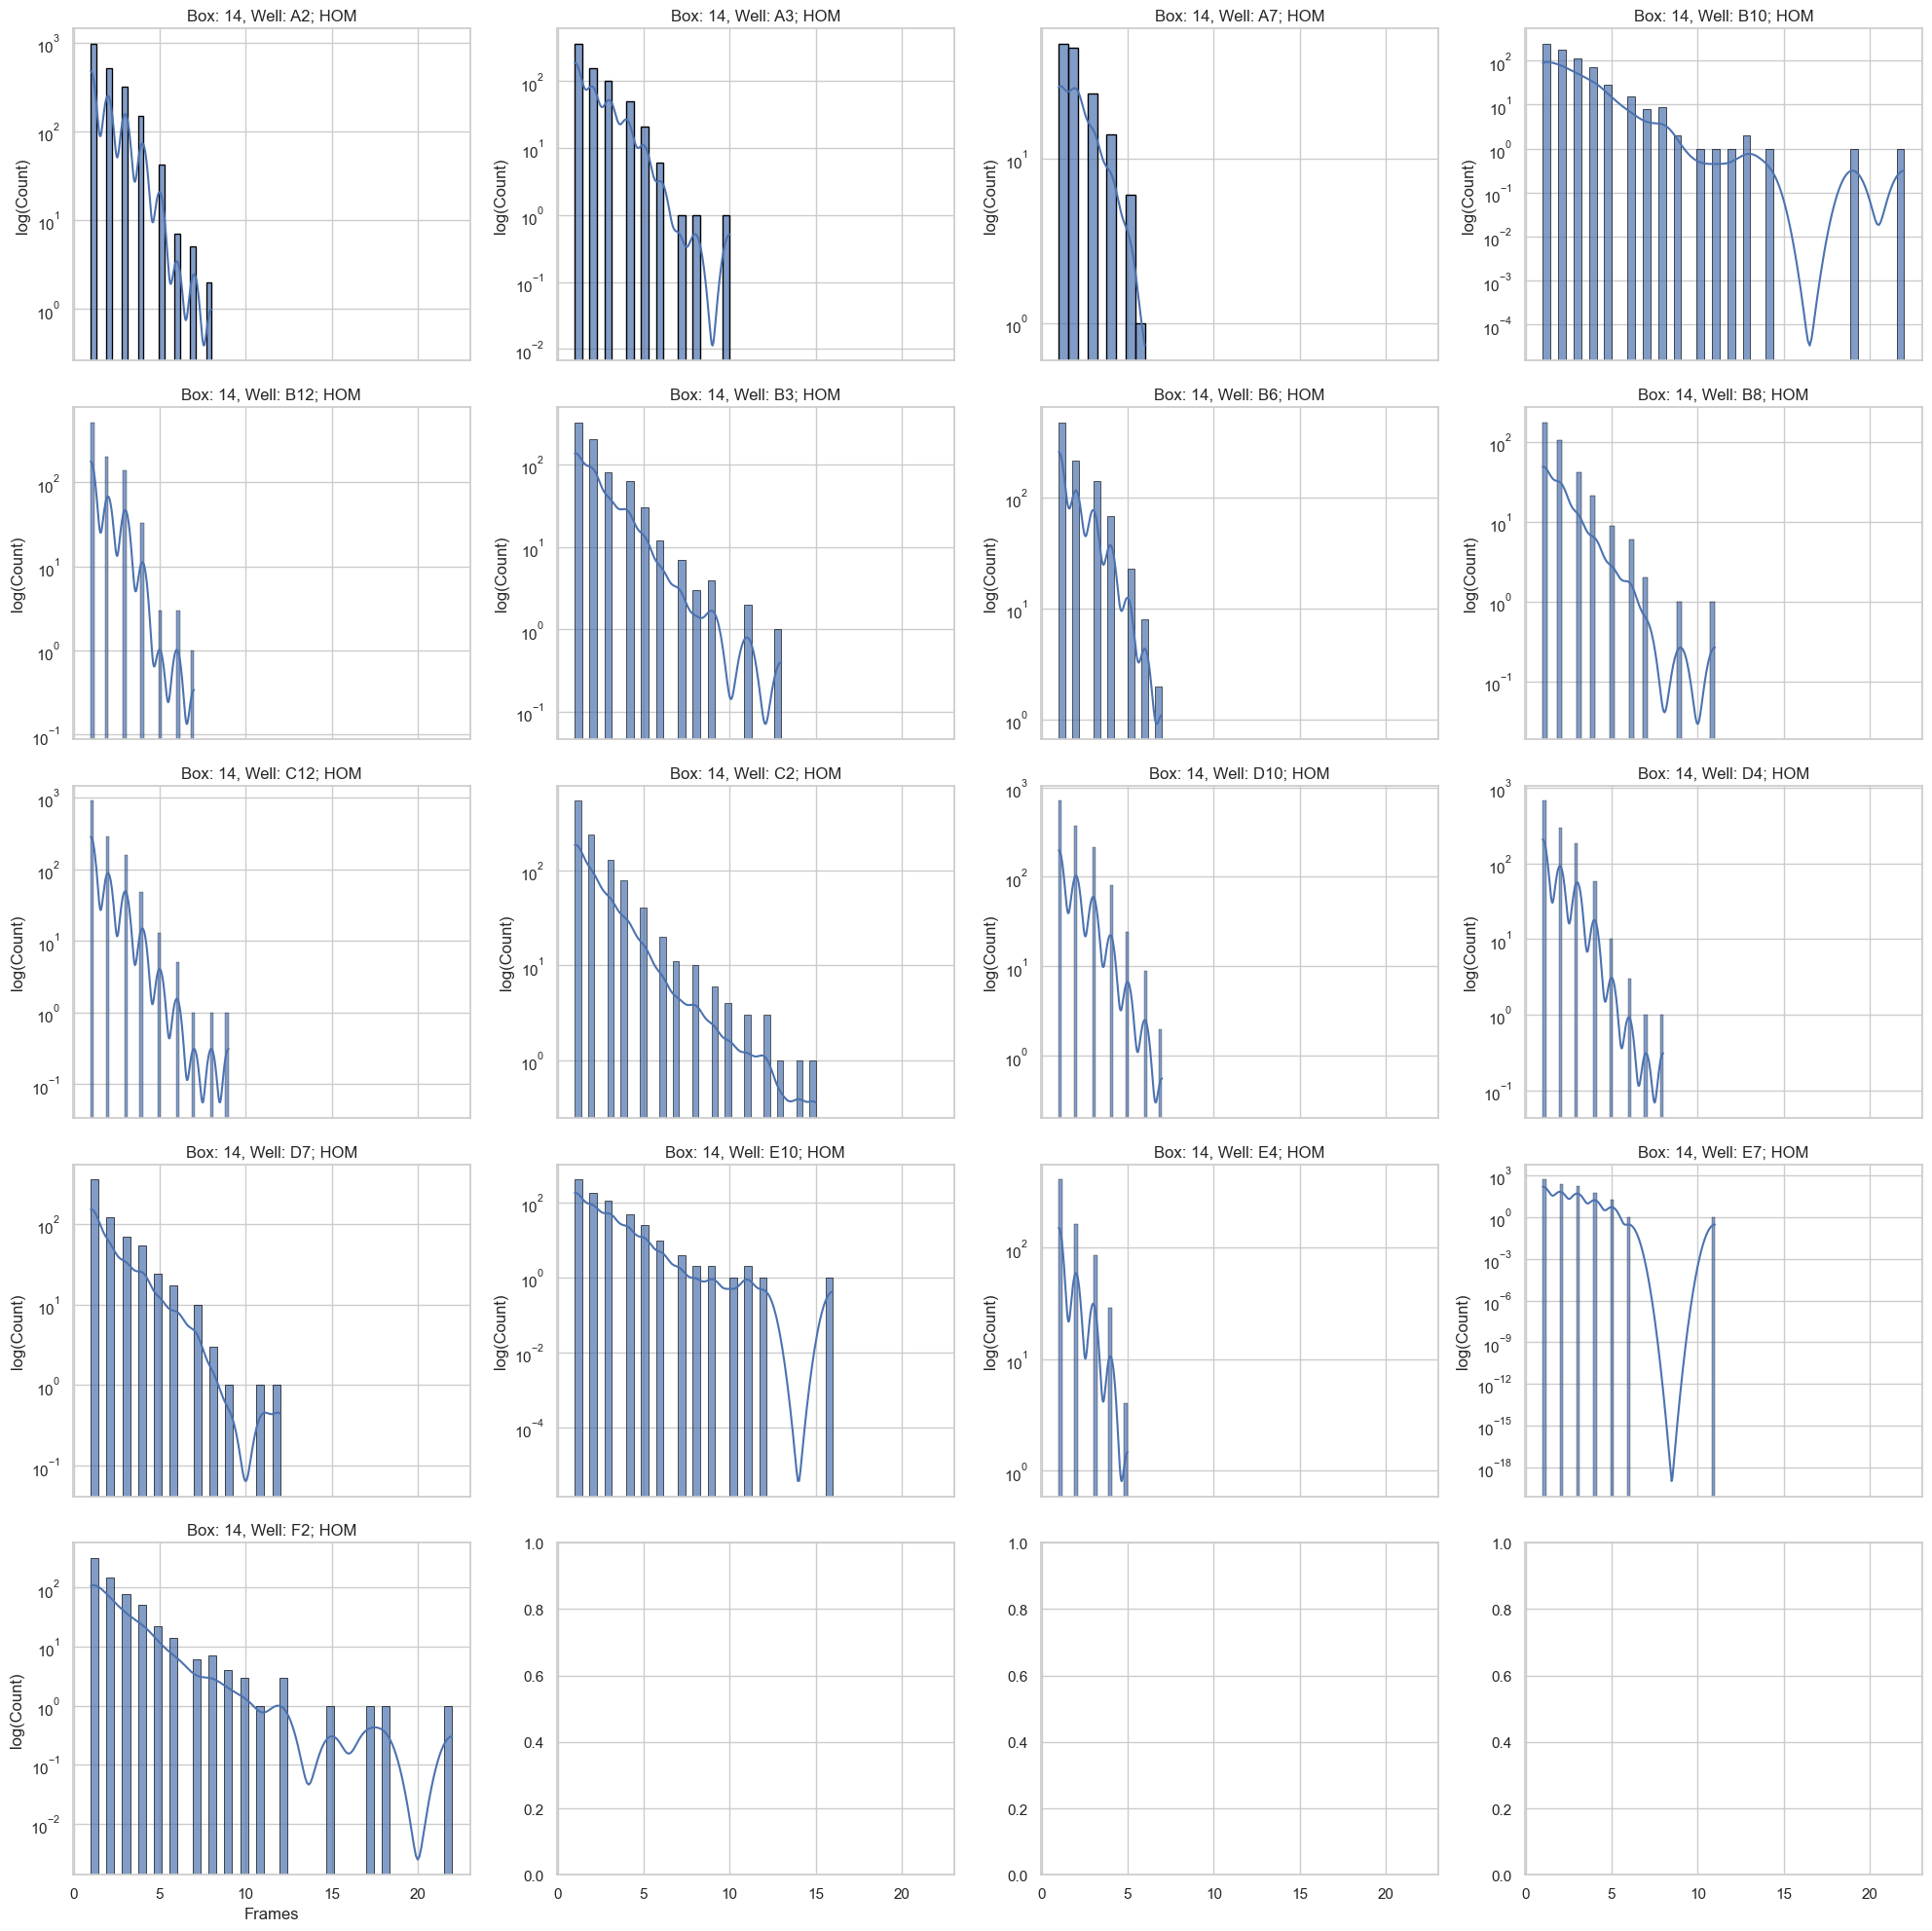

In [262]:
all_homs = df_raw[df_raw["genotype"] == "HOM"]
all_homs_grouped = list(all_homs.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_homs_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list)

Frame counts where data1 exceeded the threshold (167, 167.5): [4, 2, 1, 2, 2, 2, 1, 1, 4, 1, 1, 1, 3, 2, 1, 2, 1, 1, 5, 1, 6, 2, 4, 1, 4, 6, 1, 3, 2, 1, 1, 2, 1, 1, 2, 2, 3, 1, 3, 2, 1, 1, 1, 1, 2, 1, 4, 1, 2, 2, 3, 1, 1, 1, 6, 1, 4, 2, 1, 2, 2, 3, 1, 1, 2, 1, 4, 1, 1, 1, 1, 2, 2, 2, 1, 1, 3, 1, 1, 3, 1, 2, 1, 2, 5, 1, 1, 1, 2, 3, 2, 2, 1, 2, 1, 1, 2, 1, 3, 1, 3, 2, 5, 4, 3, 1, 2, 2, 2, 1, 3, 5, 1, 2, 1, 2, 4, 1, 1, 2, 1, 1, 1, 3, 1, 1, 1, 1, 3, 2, 1, 1, 1, 2, 4, 2, 1, 2, 1, 4, 2, 1, 1, 3, 4, 2, 4, 1, 1, 4, 1, 1, 1, 5, 1, 4, 2, 1, 3, 1, 2, 1, 5, 2, 8, 3, 2, 3, 1, 3, 2, 2, 1, 3, 1, 1, 1, 1, 1, 1, 2, 1, 3, 2, 1, 3, 1, 4, 1, 1, 1, 3, 2, 1, 1, 1, 2, 1, 1, 3, 3, 1, 1, 2, 1, 3, 2, 1, 1, 4, 1, 1, 2, 2, 2, 2, 3, 1, 3, 2, 1, 1, 1, 1, 2, 1, 3, 3, 3, 1, 1, 1, 1, 1, 3, 3, 1, 2, 3, 2, 1, 2, 6, 3, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 4, 1, 2, 1, 3, 3, 4, 3, 1, 2, 1, 2, 1, 1, 3, 2, 1, 1, 1, 1, 4, 1, 2, 1, 3, 1, 1, 5, 1, 4, 2, 3, 2, 2, 3, 3, 3, 1, 2, 5, 3, 2, 3, 1, 4, 1, 2, 3, 3, 1, 3

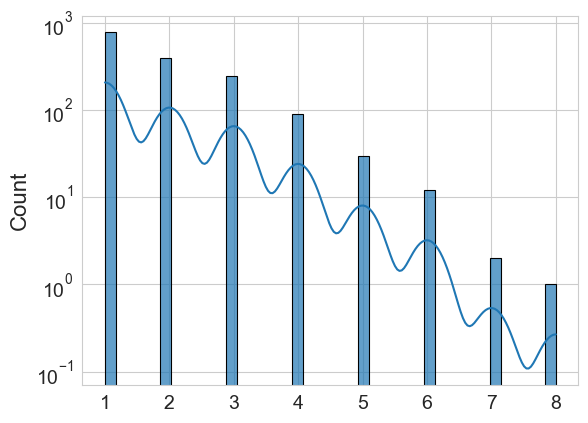

In [126]:



fishA1        = df_raw[df_raw['well'] == 'A1'] #WT

# Define threshold
threshold = 40

# Ensure data is sorted by time
df = fishA1.sort_values(by="fullts")

# Create a boolean column indicating if data1 is above the threshold
df["above_threshold"] = df["data1"] >= threshold

# Initialize variables
frame_count = 0
count_durations = []  # List to store number of frames in each threshold exceedance
above_threshold = False  # Track whether we're in a threshold-exceeding period

# Iterate through dataframe using .itertuples() (more efficient)
for row in df.itertuples(index=False):
    if row.above_threshold:
        if not above_threshold:  # First frame crossing threshold
            frame_count = 1  # Start counting
            above_threshold = True
        else:
            frame_count += 1  # Keep counting frames
    else:
        if above_threshold:  # Just dropped below threshold
            count_durations.append(frame_count)  # Store frame count
            above_threshold = False
            frame_count = 0  # Reset counter

# If the last value was still above the threshold, store the final count
if above_threshold:
    count_durations.append(frame_count)

# Output the frame count durations
print(f"Frame counts where data1 exceeded the threshold ({start}, {end}):", count_durations)
fishA1_count_durations = count_durations
ax = sns.histplot(fishA1_count_durations, kde=True, edgecolor="black", alpha=0.7)
ax.set_yscale("log")

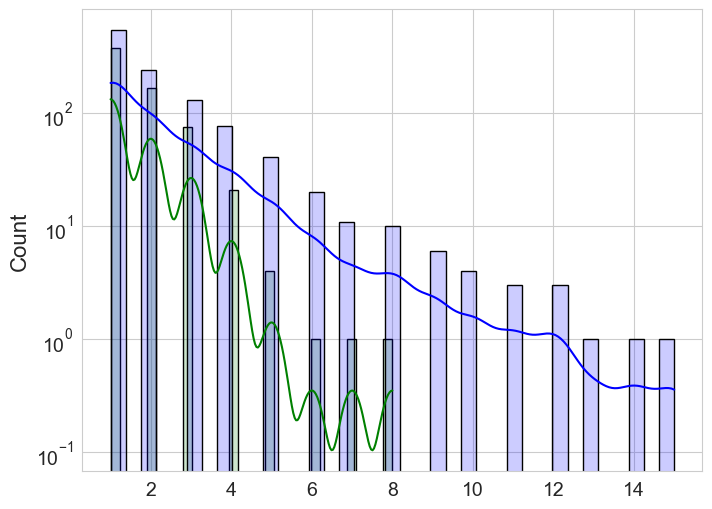

In [122]:
plt.figure(figsize=(8, 6))
    
# Plot first series
sns.histplot(hetE6_count_durations, kde=True, color="green", edgecolor="black", alpha=0.2, label='E6, HET')

# # Plot second series
sns.histplot(homC2_count_durations, kde=True, color="blue", edgecolor="black", alpha=0.2, label='C2, HOM')


plt.yscale("log")

plt.show()